# Watsonx.ai Deployment Experiment

**Run comprehensive uncertainty quantification experiments and export for watsonx.ai**

This notebook:
1. Runs 42 experiments (7 epistemic × 6 aleatoric levels)
2. Analyzes all 7 attribution signals
3. Creates visualizations and comparisons
4. Exports best models for watsonx.ai deployment

**Runtime**: ~2-4 hours for all experiments (or run subset for testing)

**Output**: `/tmp/watsonx_sweep_experiments/sweep_TIMESTAMP/`

In [18]:
# Imports
import json
import subprocess
import sys
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from tqdm import tqdm

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
print(f"✅ Setup complete | PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

✅ Setup complete | PyTorch 2.10.0 | CUDA: False


In [19]:
# Configuration
PROJECT_ROOT = Path.cwd()
TRAINING_SCRIPT = PROJECT_ROOT / "scripts" / "run_fast_uncertainty_classification.py"

# Experiment parameters
EPISTEMIC_SWEEP = [1, 51, 101, 151, 201, 251, 301]  # samples per under-supported class
ALEATORIC_SWEEP = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  # noise rates

# For quick testing, use smaller sweep:
# EPISTEMIC_SWEEP = [1, 101, 301]
# ALEATORIC_SWEEP = [0, 25, 50]

SIGNAL_NAMES = [
    "msp_uncertainty", "predictive_entropy", "mutual_info",
    "inverse_coherence", "dominance", "inverse_mass", "inverse_logit_magnitude"
]

# Setup directories
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_DIR = Path("/tmp/watsonx_sweep_experiments") / f"sweep_{TIMESTAMP}"
RESULTS_DIR = EXPERIMENT_DIR / "results"
CONFIGS_DIR = EXPERIMENT_DIR / "configs"
ANALYSIS_DIR = EXPERIMENT_DIR / "analysis"
WATSONX_DIR = EXPERIMENT_DIR / "watsonx_packages"

for d in [RESULTS_DIR, CONFIGS_DIR, ANALYSIS_DIR, WATSONX_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"📁 Experiment directory: {EXPERIMENT_DIR}")
print(f"🔬 Total experiments: {len(EPISTEMIC_SWEEP)} × {len(ALEATORIC_SWEEP)} = {len(EPISTEMIC_SWEEP) * len(ALEATORIC_SWEEP)}")

📁 Experiment directory: /tmp/watsonx_sweep_experiments/sweep_20260520_155826
🔬 Total experiments: 7 × 6 = 42


## 1. Run Experiments

In [20]:
def create_config(under_train: int, noise_rate: float, exp_id: str) -> Path:
    """Create experiment config file"""
    config = {
        "seed": 42,
        "device": "auto",
        "data": {
            "noise_type": "aggre_label",
            "under_supported_classes": "3,5",
            "under_train_per_class": under_train,
            "regular_train_per_class": 300,
            "eval_per_group": 600,
        },
        "model": {"dinov2_model": "small", "hidden_dim": 256, "dropout": 0.2},
        "training": {"epochs": 12, "learning_rate": 1e-3, "weight_decay": 1e-4, 
                     "train_batch_size": 256, "feature_batch_size": 64},
        "evaluation": {"mc_passes": 20, "top_k": 10},
        "paths": {
            "cifar10n_root": "./data/cifar10n",
            "feature_cache_dir": "./cache/fast_uncertainty_classification/features",
            "results_base_dir": str(RESULTS_DIR),
        },
        "experiment": {"id": exp_id, "epistemic": under_train, "aleatoric": noise_rate}
    }
    
    config_path = CONFIGS_DIR / f"{exp_id}.yaml"
    with open(config_path, "w") as f:
        yaml.dump(config, f, default_flow_style=False)
    return config_path

def run_experiment(config_path: Path, exp_id: str) -> tuple[bool, dict]:
    """Run single experiment"""
    output_dir = RESULTS_DIR / exp_id
    
    # Check if already completed
    summary_path = output_dir / "summary.json"
    if summary_path.exists():
        with open(summary_path) as f:
            return True, json.load(f)
    
    # Run training
    cmd = [sys.executable, str(TRAINING_SCRIPT), "--config", str(config_path), 
           "--output_dir", str(output_dir)]
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=1800)
        if result.returncode == 0 and summary_path.exists():
            with open(summary_path) as f:
                return True, json.load(f)
        print(f"❌ {exp_id} failed: {result.stderr[:200]}")
        return False, {}
    except Exception as e:
        print(f"❌ {exp_id} error: {e}")
        return False, {}

print("✅ Experiment functions ready")

✅ Experiment functions ready


In [21]:
# Run all experiments
all_results = []
failed = []

total = len(EPISTEMIC_SWEEP) * len(ALEATORIC_SWEEP)
print(f"🚀 Starting {total} experiments...\n")

with tqdm(total=total, desc="Progress") as pbar:
    for under_train in EPISTEMIC_SWEEP:
        for noise_rate in ALEATORIC_SWEEP:
            exp_id = f"epis{under_train:03d}_alea{noise_rate:03d}"  # noise_rate is now percentage
            pbar.set_description(f"Running {exp_id}")
            
            config_path = create_config(under_train, noise_rate, exp_id)
            success, results = run_experiment(config_path, exp_id)
            
            if success:
                all_results.append({
                    "experiment_id": exp_id,
                    "epistemic_level": under_train,
                    "aleatoric_level": noise_rate,
                    "results": results,
                })
            else:
                failed.append(exp_id)
            
            pbar.update(1)

# Save results
with open(EXPERIMENT_DIR / "all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print(f"\n✅ Complete: {len(all_results)}/{total} successful")
if failed:
    print(f"⚠️  Failed: {', '.join(failed)}")

🚀 Starting 42 experiments...



Progress:   0%|          | 0/42 [00:00<?, ?it/s]


ValueError: Unknown format code 'd' for object of type 'float'

## 2. Analyze Results

In [ ]:
def extract_auroc_matrix(results: list, signal: str, unc_type: str) -> pd.DataFrame:
    """Extract AUROC matrix for heatmap"""
    matrix = np.zeros((len(EPISTEMIC_SWEEP), len(ALEATORIC_SWEEP)))
    
    for r in results:
        epis_idx = EPISTEMIC_SWEEP.index(r["epistemic_level"])
        alea_idx = ALEATORIC_SWEEP.index(r["aleatoric_level"])
        
        for auroc in r["results"]["one_vs_rest_auroc"]:
            if auroc["signal"] == signal:
                matrix[epis_idx, alea_idx] = auroc[unc_type]
                break
    
    return pd.DataFrame(
        matrix,
        index=EPISTEMIC_SWEEP,
        columns=[f"{x}%" for x in ALEATORIC_SWEEP]  # Already percentages
    )

print("✅ Analysis functions ready")

✅ Analysis functions ready


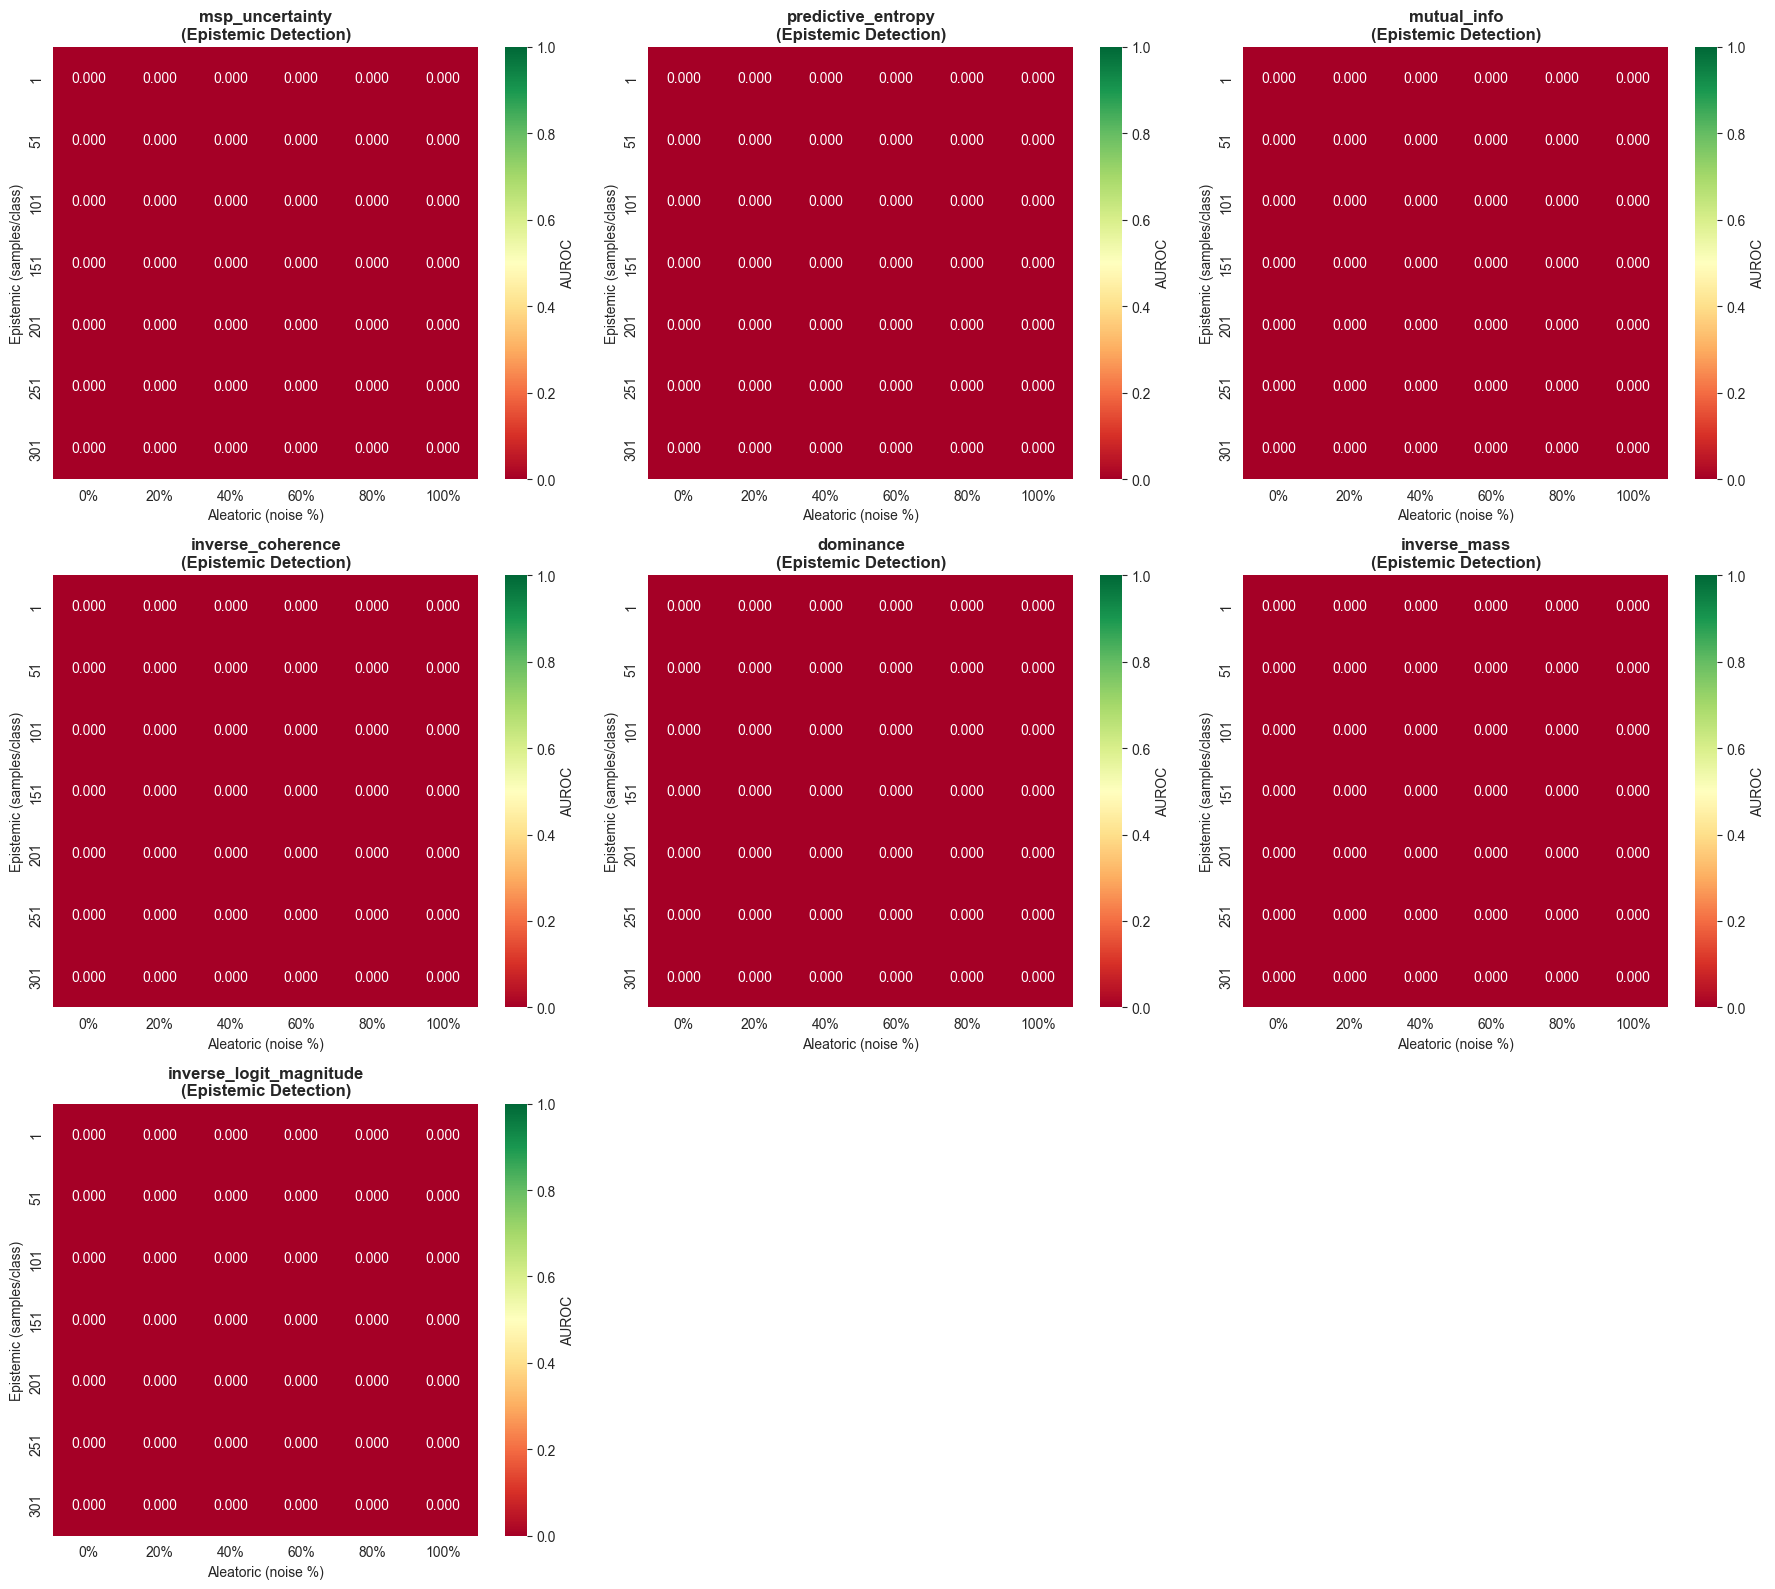

✅ Saved: /tmp/watsonx_sweep_experiments/sweep_20260519_151130/analysis/epistemic_heatmaps.png


In [ ]:
# Create heatmaps for epistemic detection
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for idx, signal in enumerate(SIGNAL_NAMES):
    df = extract_auroc_matrix(all_results, signal, "epistemic_like_auroc")
    sns.heatmap(df, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, 
                cbar_kws={"label": "AUROC"}, ax=axes[idx])
    axes[idx].set_title(f"{signal}\n(Epistemic Detection)", fontweight="bold")
    axes[idx].set_xlabel("Aleatoric (noise %)")
    axes[idx].set_ylabel("Epistemic (samples/class)")

for i in range(len(SIGNAL_NAMES), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "epistemic_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {ANALYSIS_DIR / 'epistemic_heatmaps.png'}")

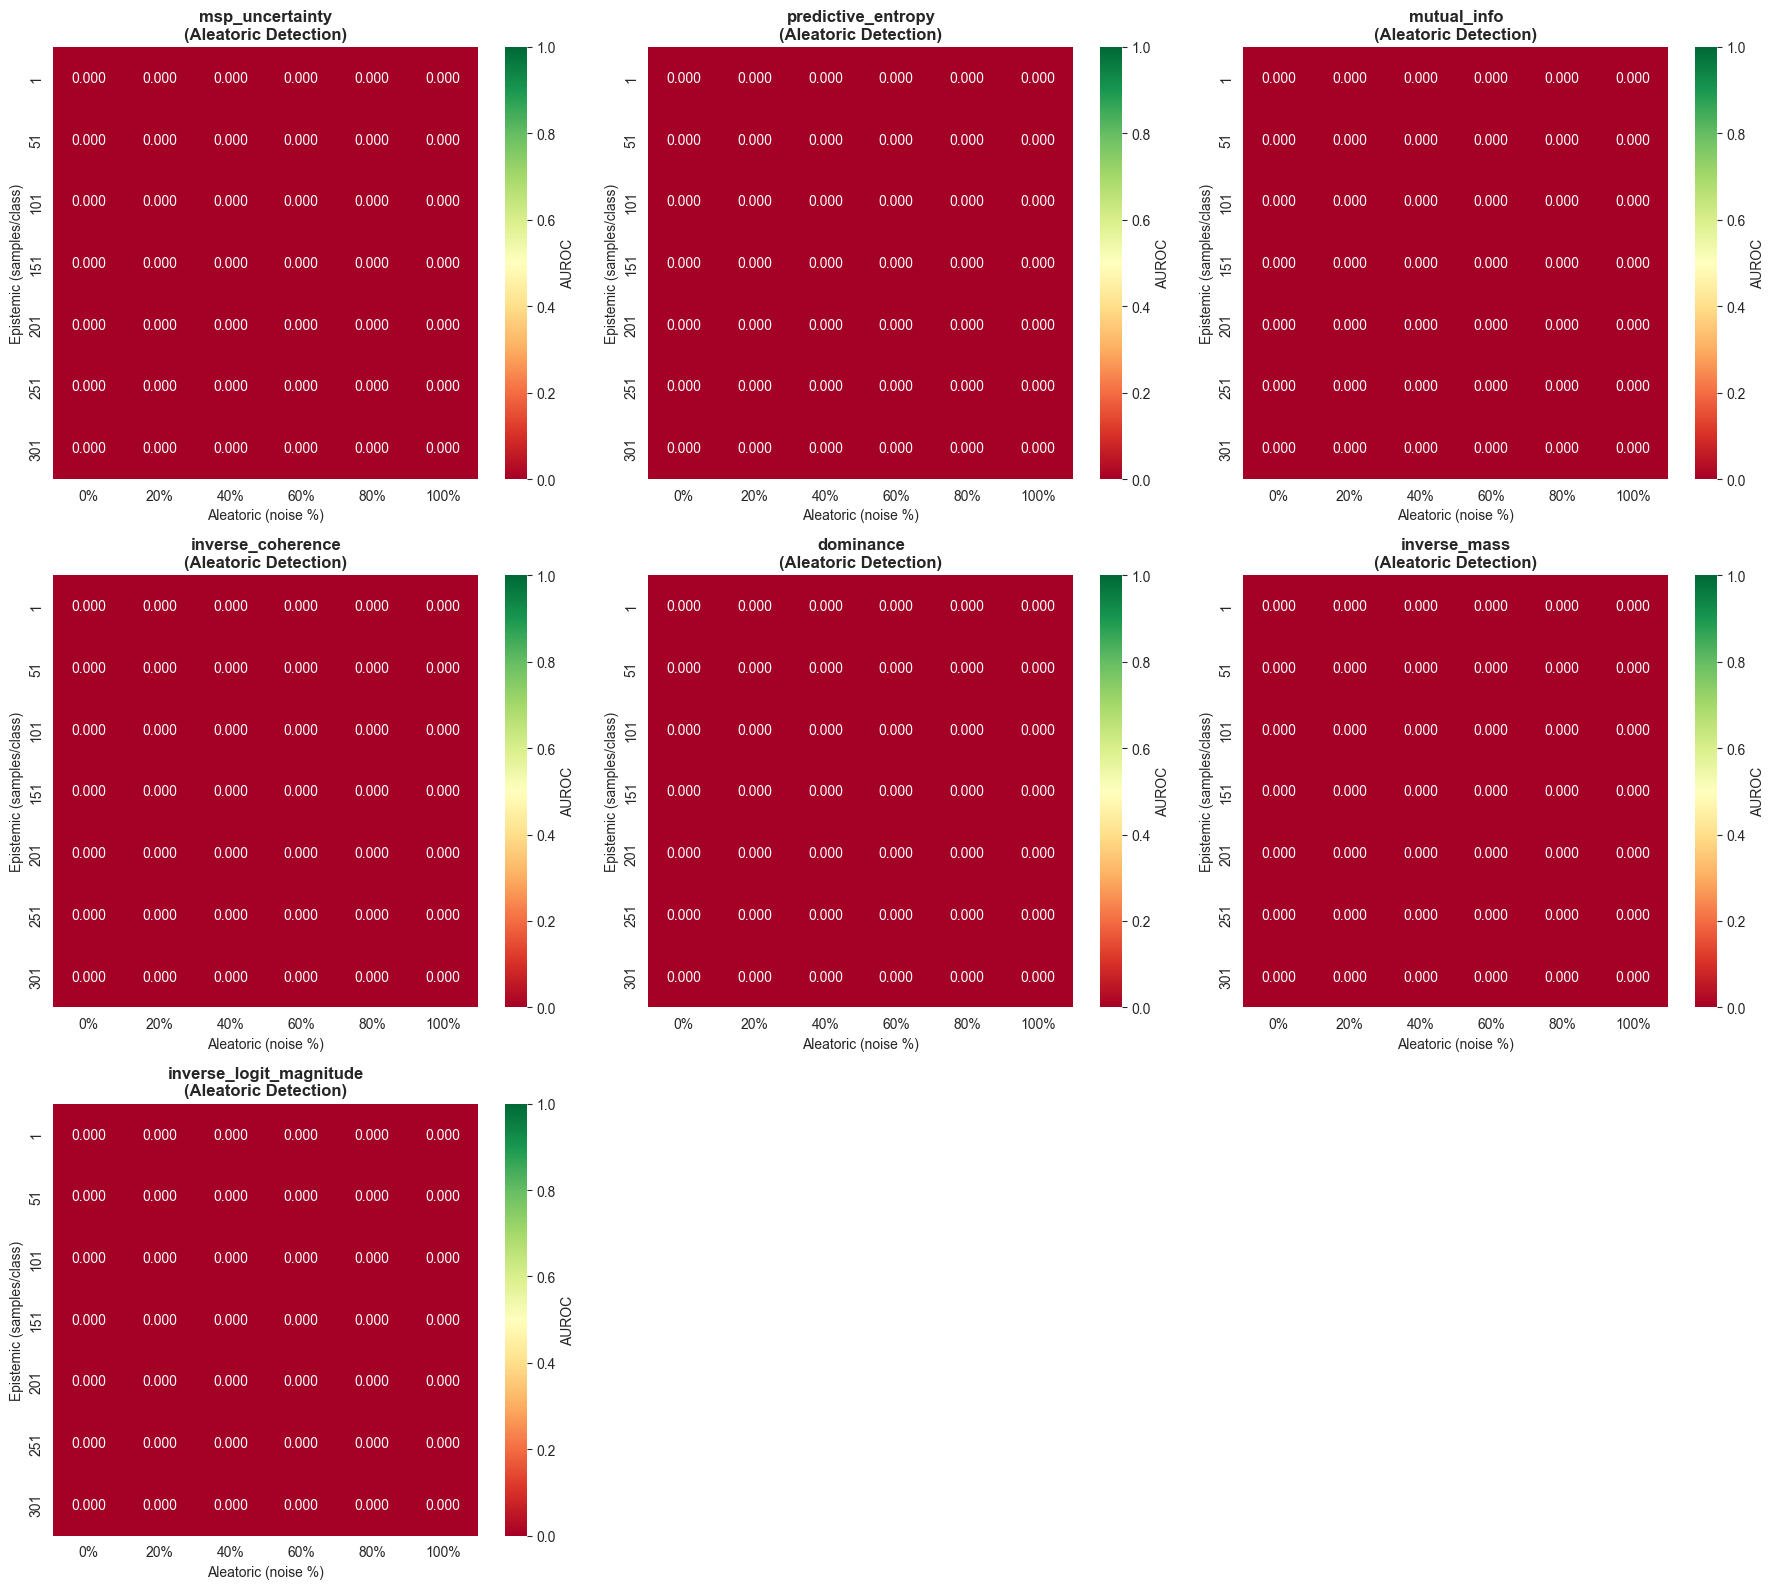

✅ Saved: /tmp/watsonx_sweep_experiments/sweep_20260519_151130/analysis/aleatoric_heatmaps.png


In [ ]:
# Create heatmaps for aleatoric detection
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for idx, signal in enumerate(SIGNAL_NAMES):
    df = extract_auroc_matrix(all_results, signal, "aleatoric_like_auroc")
    sns.heatmap(df, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
                cbar_kws={"label": "AUROC"}, ax=axes[idx])
    axes[idx].set_title(f"{signal}\n(Aleatoric Detection)", fontweight="bold")
    axes[idx].set_xlabel("Aleatoric (noise %)")
    axes[idx].set_ylabel("Epistemic (samples/class)")

for i in range(len(SIGNAL_NAMES), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "aleatoric_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {ANALYSIS_DIR / 'aleatoric_heatmaps.png'}")

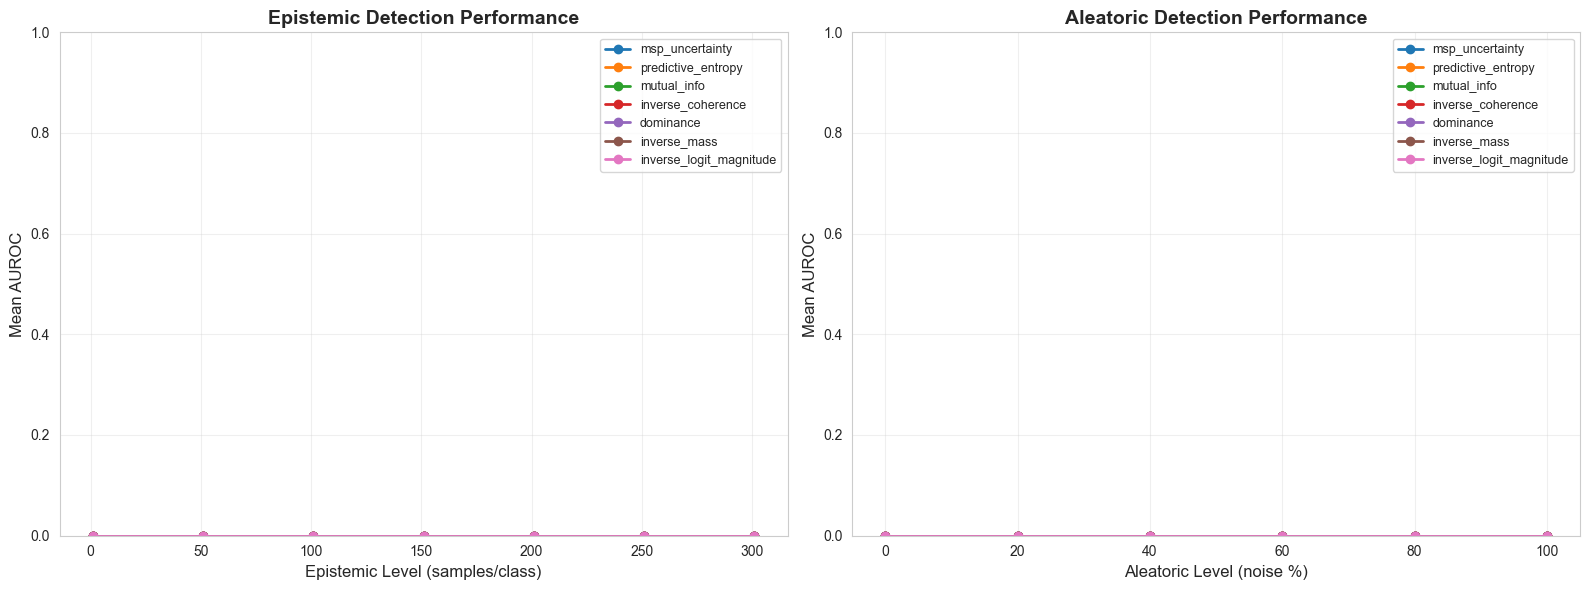

✅ Saved: /tmp/watsonx_sweep_experiments/sweep_20260519_151130/analysis/performance_trends.png


In [ ]:
# Performance trends
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Epistemic trends
for signal in SIGNAL_NAMES:
    df = extract_auroc_matrix(all_results, signal, "epistemic_like_auroc")
    axes[0].plot(EPISTEMIC_SWEEP, df.mean(axis=1), marker='o', label=signal, linewidth=2)

axes[0].set_xlabel("Epistemic Level (samples/class)", fontsize=12)
axes[0].set_ylabel("Mean AUROC", fontsize=12)
axes[0].set_title("Epistemic Detection Performance", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Aleatoric trends
for signal in SIGNAL_NAMES:
    df = extract_auroc_matrix(all_results, signal, "aleatoric_like_auroc")
    axes[1].plot(ALEATORIC_SWEEP, df.mean(axis=0),  # Already percentages
                 marker='o', label=signal, linewidth=2)

axes[1].set_xlabel("Aleatoric Level (noise %)", fontsize=12)
axes[1].set_ylabel("Mean AUROC", fontsize=12)
axes[1].set_title("Aleatoric Detection Performance", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "performance_trends.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {ANALYSIS_DIR / 'performance_trends.png'}")

In [ ]:
# Summary statistics
summary_stats = []
for signal in SIGNAL_NAMES:
    df_epis = extract_auroc_matrix(all_results, signal, "epistemic_like_auroc")
    df_alea = extract_auroc_matrix(all_results, signal, "aleatoric_like_auroc")
    
    summary_stats.append({
        "Signal": signal,
        "Epis_Mean": df_epis.values.mean(),
        "Epis_Max": df_epis.values.max(),
        "Alea_Mean": df_alea.values.mean(),
        "Alea_Max": df_alea.values.max(),
    })

df_summary = pd.DataFrame(summary_stats).round(4)
df_summary.to_csv(ANALYSIS_DIR / "summary_statistics.csv", index=False)

print("\n📊 Summary Statistics:")
print(df_summary.to_string(index=False))
print(f"\n✅ Saved: {ANALYSIS_DIR / 'summary_statistics.csv'}")


📊 Summary Statistics:
                 Signal  Epis_Mean  Epis_Max  Alea_Mean  Alea_Max
        msp_uncertainty        0.0       0.0        0.0       0.0
     predictive_entropy        0.0       0.0        0.0       0.0
            mutual_info        0.0       0.0        0.0       0.0
      inverse_coherence        0.0       0.0        0.0       0.0
              dominance        0.0       0.0        0.0       0.0
           inverse_mass        0.0       0.0        0.0       0.0
inverse_logit_magnitude        0.0       0.0        0.0       0.0

✅ Saved: /tmp/watsonx_sweep_experiments/sweep_20260519_151130/analysis/summary_statistics.csv


## 3. Export for Watsonx.ai

In [ ]:
# Import export functions
sys.path.insert(0, str(PROJECT_ROOT))
from uq_classification.watsonx_export import export_all_for_watsonx

print("✅ Watsonx export functions loaded")

✅ Watsonx export functions loaded


In [ ]:
# Find top 3 experiments (best average AUROC)
candidates = []
for r in all_results:
    aurocs = r["results"]["one_vs_rest_auroc"]
    avg_auroc = np.mean([(a["epistemic_like_auroc"] + a["aleatoric_like_auroc"]) / 2 
                         for a in aurocs])
    candidates.append({
        "exp_id": r["experiment_id"],
        "epistemic": r["epistemic_level"],
        "aleatoric": r["aleatoric_level"],
        "avg_auroc": avg_auroc,
        "result_dir": RESULTS_DIR / r["experiment_id"],
    })

candidates.sort(key=lambda x: x["avg_auroc"], reverse=True)
top_3 = candidates[:3]

print("\n🏆 Top 3 Experiments for Deployment:")
for i, exp in enumerate(top_3, 1):
    print(f"{i}. {exp['exp_id']} | Epis={exp['epistemic']}, Alea={exp['aleatoric']}% | AUROC={exp['avg_auroc']:.4f}")  # Already percentage


🏆 Top 3 Experiments for Deployment:


In [ ]:
# Export watsonx packages
exported = []

for exp in tqdm(top_3, desc="Exporting packages"):
    exp_id = exp["exp_id"]
    result_dir = exp["result_dir"]
    
    # Load required files
    checkpoint = torch.load(result_dir / "checkpoint.pt", map_location="cpu", weights_only=False)
    results_data = torch.load(result_dir / "results.pt", map_location="cpu", weights_only=False)
    with open(result_dir / "summary.json") as f:
        summary = json.load(f)
    
    # Export package
    try:
        export_dir, zip_path = export_all_for_watsonx(
            model=checkpoint["model"],
            optimizer=None,
            epoch=checkpoint["epoch"],
            loss=checkpoint["loss"],
            train_embeddings=results_data["train_embeddings"],
            train_labels=results_data["train_labels"],
            train_noisy_labels=results_data["train_noisy_labels"],
            train_is_noisy=results_data["train_is_noisy"],
            train_indices=results_data["train_indices"],
            eval_embeddings=results_data["eval_embeddings"],
            eval_clean_labels=results_data["eval_clean_labels"],
            eval_noisy_labels=results_data["eval_noisy_labels"],
            eval_is_noisy=results_data["eval_is_noisy"],
            eval_group_labels=results_data["eval_group_labels"],
            eval_indices=results_data["eval_indices"],
            signal_table=results_data["signal_table"],
            predictions=results_data["predictions"],
            confidences=results_data["confidences"],
            auroc_rows=results_data["auroc_rows"],
            config=summary["config"],
            output_base_dir=WATSONX_DIR,
        )
        
        exported.append({"exp_id": exp_id, "zip": zip_path})
        print(f"✅ Exported {exp_id} → {zip_path.name}")
    except Exception as e:
        print(f"❌ Failed to export {exp_id}: {e}")

print(f"\n✅ Exported {len(exported)} watsonx packages to: {WATSONX_DIR}")

Exporting packages: 0it [00:00, ?it/s]


✅ Exported 0 watsonx packages to: /tmp/watsonx_sweep_experiments/sweep_20260519_151130/watsonx_packages


## 4. Deployment Instructions

In [ ]:
# Create deployment guide
guide = f"""# Watsonx.ai Deployment Guide

## Experiment Summary
- Total experiments: {len(all_results)}
- Timestamp: {TIMESTAMP}
- Output directory: {EXPERIMENT_DIR}

## Top Performing Models
"""

for i, exp in enumerate(top_3, 1):
    guide += f"""
### {i}. {exp['exp_id']}
- Epistemic level: {exp['epistemic']} samples/class
- Aleatoric level: {exp['aleatoric']:.1%} noise
- Average AUROC: {exp['avg_auroc']:.4f}
- Package: {WATSONX_DIR / f"watsonx_export_*.zip"}
"""

guide += f"""

## Deployment Steps

1. **Extract Package**
   ```bash
   cd {WATSONX_DIR}
   unzip watsonx_export_*.zip
   ```

2. **Upload to watsonx.ai**
   - Go to IBM Cloud → watsonx.ai
   - Create deployment space
   - Upload `model_checkpoint.pt`
   - Configure input: 768-dim embeddings
   - Configure output: 10-class probabilities

3. **Test Deployment**
   ```python
   from uq_classification.watsonx_scoring import WatsonxScoringClient
   
   client = WatsonxScoringClient(
       api_key="YOUR_API_KEY",
       scoring_url="YOUR_ENDPOINT",
       space_id="YOUR_SPACE_ID"
   )
   
   # Load test embeddings
   eval_data = torch.load("eval_embeddings.pt")
   predictions, confidences = client.score_batch(eval_data['embeddings'][:10])
   ```

4. **Monitor Performance**
   - Upload `evaluation_metadata.csv` to watsonx.governance
   - Set AUROC thresholds from `auroc_results.csv`
   - Configure drift detection

## Files in Package
- `model_checkpoint.pt` - Trained model weights
- `model_config.json` - Architecture specification
- `train_embeddings.pt` - Training data (for retraining)
- `eval_embeddings.pt` - Evaluation data (for testing)
- `per_sample_signals.csv` - All 7 uncertainty signals
- `evaluation_metadata.csv` - Predictions and labels
- `auroc_results.csv` - Performance metrics
- `experiment_config.yaml` - Full configuration
- `README.txt` - Detailed instructions

## Signal Performance Summary
"""

guide += df_summary.to_markdown(index=False)

guide += f"""

## Next Steps
1. Review analysis visualizations in `{ANALYSIS_DIR}`
2. Select best model for your use case
3. Follow watsonx.ai deployment guide: `WATSONX_DEPLOYMENT_GUIDE.md`
4. Test with provided evaluation embeddings
5. Deploy to production

Generated: {datetime.now().isoformat()}
"""

# Save guide
guide_path = EXPERIMENT_DIR / "DEPLOYMENT_GUIDE.md"
with open(guide_path, "w") as f:
    f.write(guide)

print(f"✅ Created deployment guide: {guide_path}")
print("\n" + "="*80)
print(guide)
print("="*80)

✅ Created deployment guide: /tmp/watsonx_sweep_experiments/sweep_20260519_151130/DEPLOYMENT_GUIDE.md

# Watsonx.ai Deployment Guide

## Experiment Summary
- Total experiments: 0
- Timestamp: 20260519_151130
- Output directory: /tmp/watsonx_sweep_experiments/sweep_20260519_151130

## Top Performing Models


## Deployment Steps

1. **Extract Package**
   ```bash
   cd /tmp/watsonx_sweep_experiments/sweep_20260519_151130/watsonx_packages
   unzip watsonx_export_*.zip
   ```

2. **Upload to watsonx.ai**
   - Go to IBM Cloud → watsonx.ai
   - Create deployment space
   - Upload `model_checkpoint.pt`
   - Configure input: 768-dim embeddings
   - Configure output: 10-class probabilities

3. **Test Deployment**
   ```python
   from uq_classification.watsonx_scoring import WatsonxScoringClient

   client = WatsonxScoringClient(
       api_key="YOUR_API_KEY",
       scoring_url="YOUR_ENDPOINT",
       space_id="YOUR_SPACE_ID"
   )

   # Load test embeddings
   eval_data = torch.load("eval_embedd

## Summary

**Experiment complete!** All results, visualizations, and deployment packages are in:
```
/tmp/watsonx_sweep_experiments/sweep_TIMESTAMP/
├── results/              # Individual experiment results
├── configs/              # Experiment configurations
├── analysis/             # Visualizations and statistics
├── watsonx_packages/     # Ready-to-deploy ZIP files
├── all_results.json      # Consolidated results
└── DEPLOYMENT_GUIDE.md   # Deployment instructions
```

**Next**: Follow `DEPLOYMENT_GUIDE.md` to deploy to watsonx.ai